In [1]:
import torch
from torch import nn
from torch import cuda
from torch.optim import *
from torch import tensor
from torch.utils.data import DataLoader, Dataset

import os
import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt
import cv2 as cv

In [2]:
print("CUDA Available:", cuda.is_available())

CUDA Available: True


/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)


In [3]:
CLASSES = ["good", "major_rust", "scratches", "total_rust"]

In [4]:
CHOSEN_PART = "metal_plate"

In [5]:
good_parts_train = sorted(os.listdir(f"{CHOSEN_PART}/train/good"))[0::1]
good_parts_test = sorted(os.listdir(f"{CHOSEN_PART}/test/good"))[0::1]
for i in range(len(good_parts_train)):
    good_parts_train[i] = f"{CHOSEN_PART}/train/good/{good_parts_train[i]}"
for i in range(len(good_parts_test)):
    good_parts_test[i] = f"{CHOSEN_PART}/test/good/{good_parts_test[i]}"
good_parts_ground_truth_train = ['good'] * len(good_parts_train)
good_parts_ground_truth_test = ['good'] * len(good_parts_test)

In [6]:
major_rust_train = sorted(os.listdir(f"{CHOSEN_PART}/test/major_rust"))[0:-4:]
major_rust_test = sorted(os.listdir(f"{CHOSEN_PART}/test/major_rust"))[-4::]
for i in range(len(major_rust_train)):
    major_rust_train[i] = f"{CHOSEN_PART}/test/major_rust/{major_rust_train[i]}"
for i in range(len(major_rust_test)):
    major_rust_test[i] = f"{CHOSEN_PART}/test/major_rust/{major_rust_test[i]}"
major_rust_ground_truth_train = ['major_rust'] * len(major_rust_train)
major_rust_ground_truth_test = ['major_rust'] * len(major_rust_test)

In [7]:
scratches_train = sorted(os.listdir(f"{CHOSEN_PART}/test/scratches"))[0::2]
scratches_test = sorted(os.listdir(f"{CHOSEN_PART}/test/scratches"))[1::2]
for i in range(len(scratches_train)):
    scratches_train[i] = f"{CHOSEN_PART}/test/scratches/{scratches_train[i]}"
for i in range(len(scratches_test)):
    scratches_test[i] = f"{CHOSEN_PART}/test/scratches/{scratches_test[i]}"
scratches_ground_truth_train = ['scratches'] * len(scratches_train)
scratches_ground_truth_test = ['scratches'] * len(scratches_test)

In [8]:
total_rust_train = sorted(os.listdir(f"{CHOSEN_PART}/test/total_rust"))[0:-4:]
total_rust_test = sorted(os.listdir(f"{CHOSEN_PART}/test/total_rust"))[-4::]
for i in range(len(total_rust_train)):
    total_rust_train[i] = f"{CHOSEN_PART}/test/total_rust/{total_rust_train[i]}"
for i in range(len(total_rust_test)):
    total_rust_test[i] = f"{CHOSEN_PART}/test/total_rust/{total_rust_test[i]}"
total_rust_ground_truth_train = ['total_rust'] * len(total_rust_train)
total_rust_ground_truth_test = ['total_rust'] * len(total_rust_test)

In [9]:
X_train = good_parts_train + major_rust_train + scratches_train + total_rust_train
X_test = good_parts_test + major_rust_test + scratches_test + total_rust_test
y_train = good_parts_ground_truth_train + major_rust_ground_truth_train + scratches_ground_truth_train + total_rust_ground_truth_train
y_test = good_parts_ground_truth_test + major_rust_ground_truth_test + scratches_ground_truth_test + total_rust_ground_truth_test

In [10]:
train_dataloader = DataLoader(list(zip(X_train, y_train)), batch_size=64, shuffle=True)
test_dataloader = DataLoader(list(zip(X_test, y_test)), batch_size=64, shuffle=False)

In [11]:
DESIRED_COUNTS = 100

In [12]:
def class_spread(training_labels):
    for cls in CLASSES:
        count = training_labels.count(cls)
        print(f"Class '{cls}': {count/len(training_labels)*100:.2f}% ({count} samples)")

In [13]:
class_spread(y_train)

Class 'good': 54.00% (54 samples)
Class 'major_rust': 10.00% (10 samples)
Class 'scratches': 17.00% (17 samples)
Class 'total_rust': 19.00% (19 samples)


Loading image: metal_plate/train/good/029.png


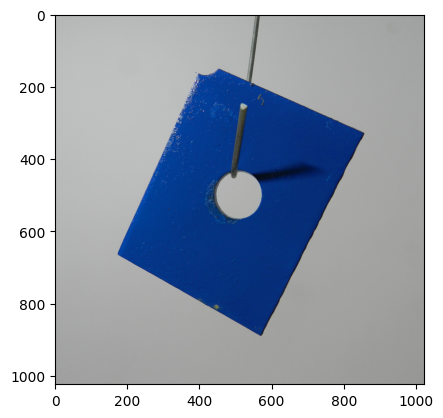

Label: good


In [14]:
chosen_index = random.randint(0, len(X_train)-1)
image_path = X_train[chosen_index]
print(f"Loading image: {image_path}")
plt.imshow(Image.open(image_path))
plt.show()
print(f"Label: {y_train[chosen_index]}")

In [15]:
# tensor_dims = (B, 3, 512, 512)

In [16]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3, 128),
            block(128, 256),
            block(256, 512),
            block(512, 1024),
            block(1024, 1024),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))
        self.fc1 = nn.Linear(1024 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, len(CLASSES))
        self.dropout = nn.Dropout(0.25)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

In [17]:
model = Classifier()
if cuda.is_available():
    model.cuda()
optimizer = Adam(model.parameters(), lr=0.001)
EPOCHS = 32

In [18]:
def load_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = image.resize((1024, 1024))
    image = np.array(image).astype(np.float32) / 255.0
    image = np.transpose(image, (2, 0, 1))  # Change to (C, H, W)
    
    return tensor(image).unsqueeze(0)  # Add batch dimension

In [19]:
model.train()
for epoch in range(EPOCHS):
    
    overall_loss = 0.0
    for i, data in enumerate(train_dataloader, 0):
        image_path, label_str = data
        image = load_image(image_path[0])
        label = CLASSES.index(label_str[0])

        if cuda.is_available():
            image = image.cuda()
            label = tensor(label).cuda().unsqueeze(0)
        
        optimizer.zero_grad()
        output = model(image)
        loss = nn.CrossEntropyLoss()(output, label)
        loss.backward()
        optimizer.step()

        overall_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} completed. Average Loss: {overall_loss/len(X_train):.4f}")
print(f"Finished Training")

Epoch 1/32 completed. Average Loss: 0.4334
Epoch 2/32 completed. Average Loss: 0.5162
Epoch 3/32 completed. Average Loss: 0.7434
Epoch 4/32 completed. Average Loss: 0.0000
Epoch 5/32 completed. Average Loss: 0.1226
Epoch 6/32 completed. Average Loss: 0.0397
Epoch 7/32 completed. Average Loss: 0.6736
Epoch 8/32 completed. Average Loss: 0.5745
Epoch 9/32 completed. Average Loss: 0.6979
Epoch 10/32 completed. Average Loss: 0.1488
Epoch 11/32 completed. Average Loss: 0.0259
Epoch 12/32 completed. Average Loss: 0.1799
Epoch 13/32 completed. Average Loss: 0.2338
Epoch 14/32 completed. Average Loss: 0.1649
Epoch 15/32 completed. Average Loss: 0.1672
Epoch 16/32 completed. Average Loss: 0.0000
Epoch 17/32 completed. Average Loss: 0.0000
Epoch 18/32 completed. Average Loss: 0.3061
Epoch 19/32 completed. Average Loss: 0.0631
Epoch 20/32 completed. Average Loss: 0.2899
Epoch 21/32 completed. Average Loss: 0.1346
Epoch 22/32 completed. Average Loss: 0.0000
Epoch 23/32 completed. Average Loss: 0.00

In [20]:
VERSION = "1c"
MODEL_NAME = f"{CHOSEN_PART}_{VERSION}_classifier.pth"
torch.save(model.state_dict(), MODEL_NAME)

In [21]:
classifier = Classifier()
classifier.load_state_dict(torch.load(MODEL_NAME))
classifier.eval()

Classifier(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fa

In [22]:
def decode_output(output):
    _, predicted = torch.max(output, 1)
    # print(predicted)
    return CLASSES[predicted.item()]

In [26]:
with torch.no_grad():
    selected_index = random.randint(0, len(X_test)-1)
    image_path = X_test[selected_index]
    print(f"Loading image: {image_path}")
    image_tensor = load_image(X_test[selected_index])
    y = y_test[selected_index]
    outputs = classifier(image_tensor)

Loading image: metal_plate/test/total_rust/022.png


In [27]:
print(list(zip(CLASSES, outputs[0].tolist())))

[('good', 1.11705482006073), ('major_rust', -33.14684295654297), ('scratches', 14.952349662780762), ('total_rust', 16.04563331604004)]


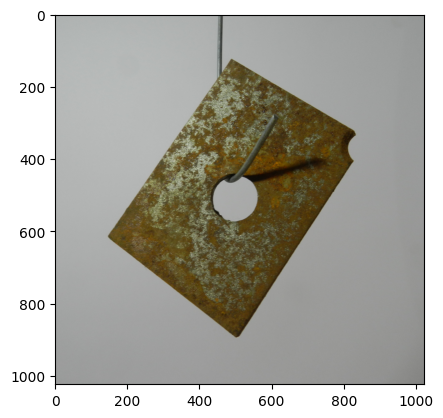

Ground Truth: total_rust
Predicted Class: total_rust


In [28]:
plt.imshow(Image.open(image_path))
plt.show()
print(f"Ground Truth: {y}")
print("Predicted Class:", decode_output(outputs))